# Getting Started with QMCPy

This notebook gives a hands‑on tour of the QMCPy library:

1. Import `qmcpy` as `qp`.
2. Compare IID points, grids, and low‑discrepancy (LD) sequences using `plot_proj`.
3. Use `TrueMeasure` objects to transform LD points to other distributions.
4. Build integrands with `CustomFun` and with built‑in integrand classes; compare LD vs IID.
5. Introduce QMCPy's adaptive stopping criteria.
6. Work through short examples: option pricing, control variates, and importance sampling.

The emphasis is on *how the four core QMCPy components fit together*:

- `DiscreteDistribution` (where the points live),
- `TrueMeasure` (which distribution we integrate over),
- `Integrand` (the function whose expectation we want),
- `StoppingCriterion` (how we decide when we are accurate enough).

#### Some LaTeX macros (hidden in math mode, will not render correctly in VS Code)
$
\newcommand{\vh}{\boldsymbol{h}}
\newcommand{\vt}{\boldsymbol{t}}
\newcommand{\vx}{\boldsymbol{x}}
\newcommand{\vz}{\boldsymbol{z}}
\newcommand{\vX}{\boldsymbol{X}}
\newcommand{\vU}{\boldsymbol{U}}
\newcommand{\vzero}{\boldsymbol{0}}
\newcommand{\cf}{\mathcal{F}}
\newcommand{\cn}{\mathcal{N}}
\newcommand{\cu}{\mathcal{U}}
\newcommand{\cgp}{\mathcal{G}\!\mathcal{P}}
\newcommand{\dif}{\mathrm{d}}
\newcommand{\Ex}{\mathbb{E}}
\newcommand{\Prob}{\mathbb{P}}
\newcommand{\bbone}{\mathbb{1}}
\newcommand{\reals}{\mathbb{R}}
\newcommand{\disc}{\operatorname{disc}}
\newcommand{\norm}[2]{{\left \lVert #1 \right \rVert}_{#2}}
$


#### Run this notebook in Juypter with the `conda qmcpy` environment or [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/MATH565Fall2025/blob/main/notebooks/QMCPy_Introduction.ipynb?flush_cache=true)

In [1]:
# Colab-only setup
if "google.colab" in str(get_ipython()):
    !apt-get -y install cm-super dvipng texlive-latex-extra texlive-latex-recommended
    !pip install git+https://github.com/QMCSoftware/QMCSoftware.git@develop

### Import needed packages and initialize some parameters

In [1]:
import qmcpy as qp
import classlib as cl
print("classlib from:", cl.__file__)
qp.Kronecker = cl.generators.Kronecker

classlib from: /Users/fredhickernell/SoftwareRepositories/HickernellClassLib/classlib/__init__.py


In [1]:
# ----- Standard packages -----
import sys, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import qmcpy as qp
from IPython.display import display, Markdown

# Some older code expects np.math
if not hasattr(np, "math"):
    np.math = math

# ----- Import classlib (installed or repo submodule) -----
try:
    import classlib as cl
except ImportError:
    # Fallback for students running from notebooks/ with submodule
    REPO_ROOT = Path.cwd().resolve().parent
    if str(REPO_ROOT) not in sys.path:
        sys.path.insert(0, str(REPO_ROOT))
    import classlib as cl

# Integrate our Kronecker into the qmcpy namespace
qp.Kronecker = cl.generators.Kronecker

# ----- Plotting / Style -----
%matplotlib inline

cl.nbviz.init(use_tex=True)
colors, TINY = cl.nbviz.TOL_BRIGHT, cl.nbviz.TINY
cl.nbviz.configure(figpath="QMCPy_Intro_figures", savefigs=True)

print("QMCPy version:", qp.__version__)
print("classlib path:", cl.__file__)

QMCPy version: 2.0
classlib path: /Users/fredhickernell/SoftwareRepositories/HickernellClassLib/classlib/__init__.py


## 1. Discrete distributions and low‑discrepancy (LD) points

A `DiscreteDistribution` object in QMCPy generates an $n\times d$ array of points in $[0,1)^d$:

- Rows = independent *samples*.
- Columns = *coordinates* (dimensions).

For IID sampling the rows are independent uniforms and there is no preferred ordering.
For LD sequences (Sobol', lattice, Halton, digital nets), the points are highly structured: the
first $2^m$ points are carefully chosen so that **every low‑dimensional projection looks well‑filled**.

In [3]:
d = 8  #dimension
n = 2**5  #sample size
randomize=False

samplers = {
    "iid":    {"gen": qp.IIDStdUniform(d), "label": "IID"},
    "sobol":  {"gen": qp.Sobol(d,randomize=randomize),         "label": "Sobol' LD"},
    "lattice":{"gen": qp.Lattice(d,randomize=randomize),       "label": "Lattice LD"},
    "kronecker": {"gen": qp.Kronecker(d, randomize=randomize),  "label": "Kronecker LD"},
    "halton": {"gen": qp.Halton(d,randomize=randomize),        "label": "Halton LD"}
}

x_sobol = samplers["sobol"]["gen"](n)
#x_lattice = lattice.gen_samples(n)
#x_iid = iid.gen_samples(n)

print("Sobol shape:", x_sobol.shape)
#print("Lattice shape:", x_lattice.shape)
#print("IID shape:", x_iid.shape)

x_sobol[:5]

Sobol shape: (32, 8)


/Users/fredhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/digital_net_b2/digital_net_b2.py:421: ParameterWarning: Without randomization, the first digtial net point is the origin
  warnings.warn("Without randomization, the first digtial net point is the origin",ParameterWarning)


array([[0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ],
       [0.5  , 0.5  , 0.5  , 0.5  , 0.5  , 0.5  , 0.5  , 0.5  ],
       [0.25 , 0.75 , 0.75 , 0.75 , 0.25 , 0.25 , 0.75 , 0.25 ],
       [0.75 , 0.25 , 0.25 , 0.25 , 0.75 , 0.75 , 0.25 , 0.75 ],
       [0.125, 0.625, 0.375, 0.125, 0.125, 0.375, 0.625, 0.625]])

Note that all three generators return arrays of shape `(n, dimension)`.

For LD sequences like Sobol' and lattice, *which column is which coordinate matters*:

- Column 0 always holds the first coordinate $x^{(1)}$ of every sample.
- Column 1 always holds the second coordinate $x^{(2)}$, etc.

The LD construction is designed so that

- the 1D projections (each column) are well‑spread,
- the 2D projections (pairs of columns) avoid clumping on diagonals,
- higher‑dimensional projections fill the hypercube evenly.

By contrast, for IID points the columns are exchangeable – permuting coordinates gives another IID sample from the same distribution.

### 1.1 Visualizing projections with `plot_proj`

QMCPy includes a helper `plot_proj` that plots 2D projections of a `DiscreteDistribution`.
This is a quick way to *see* the difference between IID points and LD points.

/Users/fredhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/digital_net_b2/digital_net_b2.py:421: ParameterWarning: Without randomization, the first digtial net point is the origin
  warnings.warn("Without randomization, the first digtial net point is the origin",ParameterWarning)
/Users/fredhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/lattice/lattice.py:248: ParameterWarning: Without randomization, the first lattice point is the origin
  warnings.warn("Without randomization, the first lattice point is the origin",ParameterWarning)
/Users/fredhickernell/SoftwareRepositories/QMCSoftware/qmcpy/discrete_distribution/halton.py:263: UserWarning: Without randomization, the first Halton point is the origin
  warnings.warn("Without randomization, the first Halton point is the origin")


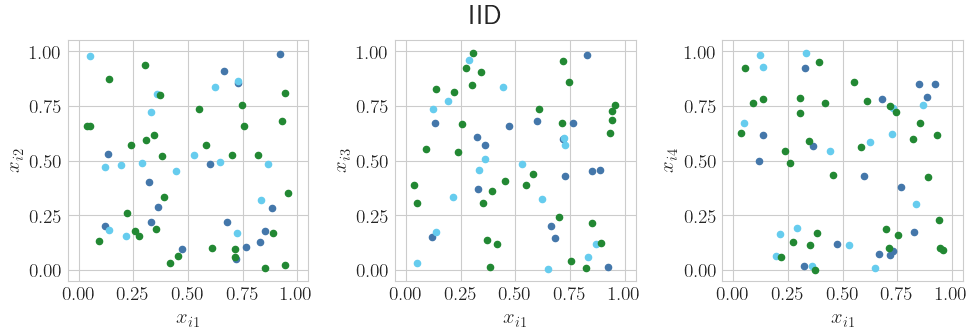

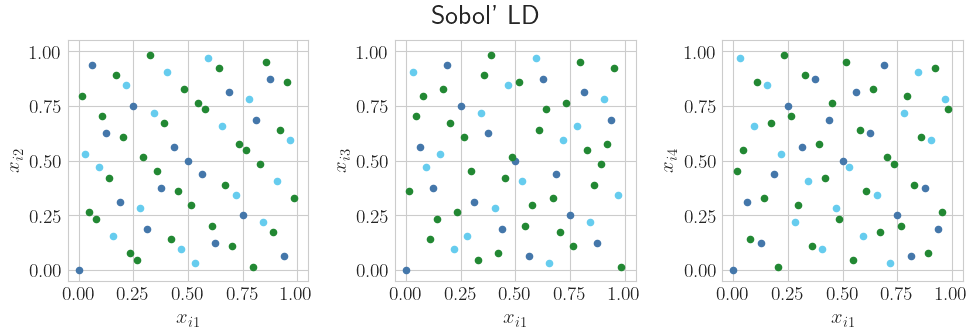

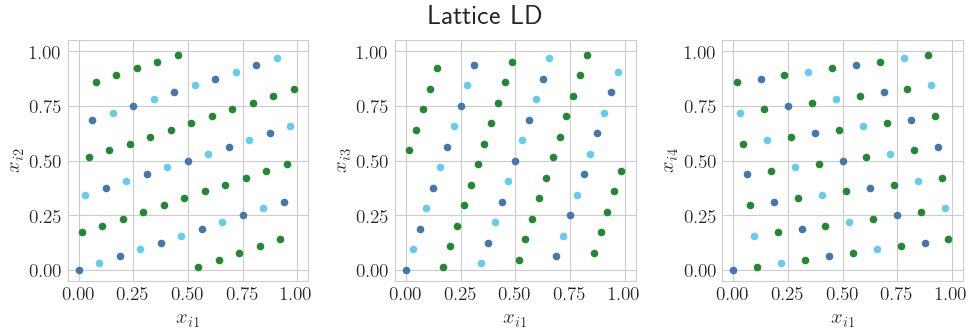

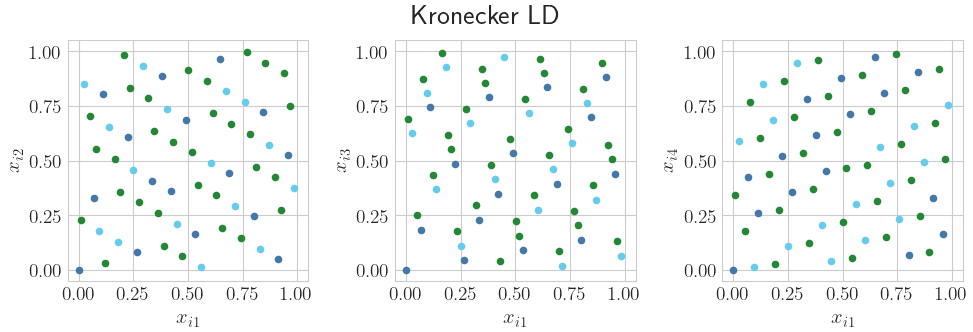

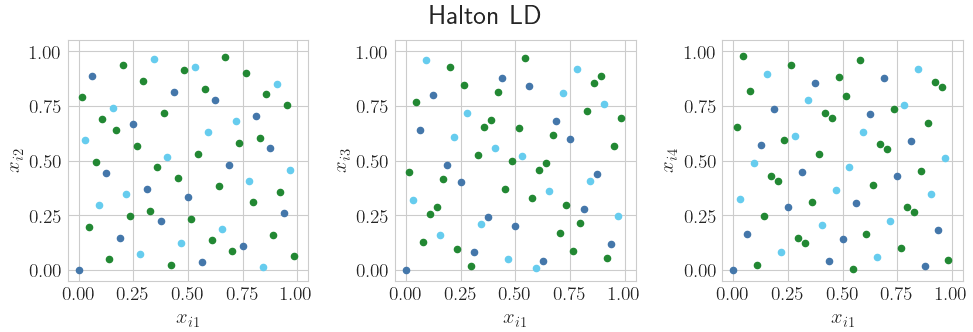

In [5]:
n_plot = [16,32, 64]
d_horiz = 1
d_vert = [2, 3, 4]

for key, s in samplers.items():
    fig, ax = qp.plot_proj(
        s["gen"],
        n=n_plot,
        d_horizontal=d_horiz,
        d_vertical=d_vert,
        axis_pad=0.05,
        marker_size=20,
        figfac=10,
        fig_title=s["label"],
        where_title=0.545,
    )
    cl.nbviz.savefig(s["label"])


### 1.2 Grids vs LD vs IID

For comparison, here is a simple $8\times 8$ tensor‑product grid in 2D. Grids line up on a
rigid lattice; LD sequences look *irregular but very even*; IID points look noisy:


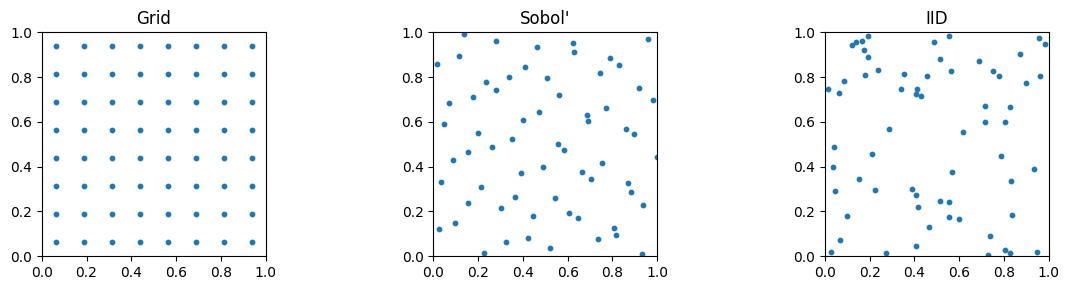

In [3]:
m = 8
u = np.linspace(0, 1, m, endpoint=False) + 0.5/m
U1, U2 = np.meshgrid(u, u)

grid_points = np.column_stack([U1.ravel(), U2.ravel()])

sobol2 = qp.Sobol(dimension=2)
iid2 = qp.IIDStdUniform(dimension=2)

xs_sobol = sobol2.gen_samples(m**2)
xs_iid = iid2.gen_samples(m**2)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].scatter(grid_points[:, 0], grid_points[:, 1], s=10)
axes[0].set_title("Grid")
axes[1].scatter(xs_sobol[:, 0], xs_sobol[:, 1], s=10)
axes[1].set_title("Sobol'")
axes[2].scatter(xs_iid[:, 0], xs_iid[:, 1], s=10)
axes[2].set_title("IID")
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 2. From uniform to other distributions: `TrueMeasure`

A `DiscreteDistribution` generates points in $[0,1)^d$ that *mimic* a base distribution (usually standard uniform).
A `TrueMeasure` wraps a discrete distribution and transforms its points so that they mimic another distribution, such as a Gaussian.

Conceptually:

1. Start with LD points $\boldsymbol{u}_i \in [0,1)^d$ from a Sobol' or lattice generator.
2. Apply a transformation $\Psi$ coordinate‑wise (e.g., inverse Gaussian CDF) to get $\boldsymbol{x}_i = \Psi(\boldsymbol{u}_i)$.
3. Use the transformed points ${\boldsymbol{x}_i}$ to approximate expectations with respect to the new distribution.


In [ ]:
dimension = 2
n = 2**10

sobol = qp.Sobol(dimension=dimension)

# Standard uniform true measure (just returns the Sobol' points)
uniform = qp.Uniform(sobol)

# Gaussian true measure with mean 0 and covariance 1/2
# (independent coordinates with variance 1/2)
gaussian = qp.Gaussian(sobol, mean=0.0, covariance=0.5)

u_samples = uniform.gen_samples(n)
g_samples = gaussian.gen_samples(n)

print("Uniform samples shape:", u_samples.shape)
print("Gaussian samples shape:", g_samples.shape)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(u_samples[:, 0], bins=40, density=True)
axes[0].set_title("First coordinate: Uniform[0,1]")
axes[1].hist(g_samples[:, 0], bins=40, density=True)
axes[1].set_title("First coordinate: Gaussian N(0, 1/2)")
plt.tight_layout()
plt.show()

## 3. Integrands: `CustomFun` and built‑in classes

An `Integrand` represents the function whose expectation we want to estimate.

- `qp.CustomFun(true_measure, custom_fun=...)` lets you plug in any Python function.
- Built‑in integrands (e.g. `Keister`, `AsianOption`, `EuropeanOption`, etc.) wrap common test problems and finance models.

We'll start with a classic example: the Keister integral.

In [ ]:
from numpy.linalg import norm

# Keister test integrand
def keister(x):
    """x: n x d array, returns length-n vector."""
    d = x.shape[1]
    r = norm(x, axis=1)
    return np.pi**(d/2) * np.cos(r)

d = 5
sobol = qp.Sobol(dimension=d)

gaussian = qp.Gaussian(sobol, mean=0.0, covariance=0.5)
keister_integrand = qp.CustomFun(gaussian, custom_fun=keister)

keister_integrand

## 4. Adaptive stopping criteria

QMCPy separates *what* to integrate (the `Integrand`) from *how long* to integrate (the `StoppingCriterion`).

A stopping criterion object

- takes an integrand and user‑specified tolerances (absolute and/or relative),
- repeatedly requests more samples from the underlying distribution,
- stops once the estimated error is within tolerance.

Some commonly used classes are:

- `qp.CubMCG` – IID Monte Carlo with guaranteed error bounds.
- `qp.CubQMCSobolG` – QMC with Sobol' points.
- `qp.CubQMCLatticeG` – QMC with lattice points.
- `qp.CubQMCCLT` – Central Limit Theorem based error estimation.

All share the same basic interface:

```python
stopper = qp.CubQMCSobolG(integrand, abs_tol=1e-3, rel_tol=0)
solution, data = stopper.integrate()
```

In [ ]:
d = 5
abs_tol = 1e-3

# QMC: Sobol' + Gaussian + Keister
sobol = qp.Sobol(dimension=d)
keister_qmc = qp.CustomFun(qp.Gaussian(sobol, mean=0.0, covariance=0.5), custom_fun=keister)
qmc_stop = qp.CubQMCSobolG(keister_qmc, abs_tol=abs_tol, rel_tol=0)
qmc_solution, qmc_data = qmc_stop.integrate()

# MC: IID + Gaussian + Keister
iid = qp.IIDStdUniform(dimension=d)
keister_mc = qp.CustomFun(qp.Gaussian(iid, mean=0.0, covariance=0.5), custom_fun=keister)
mc_stop = qp.CubMCG(keister_mc, abs_tol=abs_tol, rel_tol=0)
mc_solution, mc_data = mc_stop.integrate()

print("Target abs tolerance:", abs_tol)
print("QMC (Sobol') solution = {:.6f}, n = {:d}".format(qmc_solution, int(qmc_data.n_total)))
print("MC  (IID)   solution = {:.6f}, n = {:d}".format(mc_solution, int(mc_data.n_total)))

Even for this small example, you should see that the Sobol' QMC method typically needs **far fewer samples** than IID Monte Carlo to hit the same error tolerance.

## 5. Example: Asian option pricing

QMCPy includes several finance integrands. Here we use an `AsianOption` to price an arithmetic‑mean call option on a geometric Brownian motion.

We'll compare:

- IID Monte Carlo (`CubMCG` with `IIDStdUniform`),
- Sobol' QMC (`CubQMCSobolG` with `Sobol`).


In [ ]:
dimension = 12  # monthly monitoring over 1 year

# IID Monte Carlo sampler and integrand
iid_points = qp.IIDStdUniform(dimension=dimension)
Asian_IID = qp.AsianOption(
    iid_points,
    volatility=0.50,
    start_price=120.0,
    strike_price=130.0,
    interest_rate=0.02,
    t_final=1.0,
    call_put='call',
    mean_type='arithmetic',
)

# Sobol' QMC sampler and integrand
sobol_points = qp.Sobol(dimension=dimension)
Asian_Sobol = qp.AsianOption(
    sobol_points,
    volatility=0.50,
    start_price=120.0,
    strike_price=130.0,
    interest_rate=0.02,
    t_final=1.0,
    call_put='call',
    mean_type='arithmetic',
)

abs_tol = 0.01

mc_stop = qp.CubMCG(Asian_IID, abs_tol=abs_tol, rel_tol=0)
qmc_stop = qp.CubQMCSobolG(Asian_Sobol, abs_tol=abs_tol, rel_tol=0)

price_mc, data_mc = mc_stop.integrate()
price_qmc, data_qmc = qmc_stop.integrate()

print("Asian call option (arithmetic mean)")
print("Target abs_tol =", abs_tol)
print("MC  price = {:.4f}, n = {:d}".format(price_mc, int(data_mc.n_total)))
print("QMC price = {:.4f}, n = {:d}".format(price_qmc, int(data_qmc.n_total)))

## 6. Variance reduction: control variates and importance sampling

Two standard variance‑reduction tricks in (Q)MC are:

- **Control variates:** subtract a function with known mean.
- **Importance sampling:** change the sampling distribution to focus on the most important regions.

QMCPy can help with both by providing flexible sampling (`DiscreteDistribution` and `TrueMeasure`) and by letting you post‑process samples in Python.

### 6.1 A simple control variate example

Suppose we want to estimate

$$\mu = \mathbb{E}[f(X)], \quad X \sim U[0,1]^d.$$

Take a function $g$ with known mean $\mathbb{E}[g(X)]$, and define

$$\tilde f(X) = f(X) - c\,(g(X) - \mathbb{E}[g(X)]).$$

Then $\mathbb{E}[\tilde f(X)] = \mu$ for any constant $c$, but for a good choice of $c$ the variance can be much smaller.

Here we'll use QMCPy just to generate nodes, and do the control‑variate algebra in NumPy.

In [ ]:
dimension = 4
n = 2**12

sobol = qp.Sobol(dimension=dimension)

def f(x):
    """Target integrand: mildly nonlinear."""
    return np.exp(x.sum(axis=1))

# Control variate: linear function with known mean
# g(x) = sum_j x_j, so E[g] = d/2 on [0,1]^d
def g(x):
    return x.sum(axis=1)

x = sobol.gen_samples(n)
fx = f(x)
gx = g(x)

mu_g = dimension / 2.0

# Optimal c (in least-squares sense) estimated from the sample
c_hat = np.cov(fx, gx, bias=True)[0, 1] / np.var(gx)

mc_plain = fx.mean()
mc_cv = (fx - c_hat * (gx - mu_g)).mean()

print("Plain QMC estimate       = {:.6f}".format(mc_plain))
print("Control variate estimate  = {:.6f}".format(mc_cv))

### 6.2 Importance sampling with QMCPy

For importance sampling, we want

$$\mu = \mathbb{E}_{X\sim p}[f(X)] = \mathbb{E}_{Y\sim q}\Bigl[f(Y)\,\frac{p(Y)}{q(Y)}\Bigr],$$

so we:

1. choose an easier proposal distribution $q$, 
2. sample $Y_i$ from $q$,
3. weight each sample by $w_i = p(Y_i)/q(Y_i)$.

QMCPy's `TrueMeasure` class makes it easy to swap $p$ and $q$ by composing different transforms.
Below is a very simple Gaussian example (done with IID points for clarity).

In [ ]:
n = 10_000

# Target: X ~ N(0, 1), proposal: Y ~ N(1, 1)

# IID uniforms for target and proposal (kept separate for clarity)
base_target = qp.IIDStdUniform(dimension=1)
base_proposal = qp.IIDStdUniform(dimension=1)

gauss_target = qp.Gaussian(base_target, mean=0.0, covariance=1.0)
gauss_proposal = qp.Gaussian(base_proposal, mean=1.0, covariance=1.0)

X = gauss_target.gen_samples(n)[:, 0]   # standard MC samples
Y = gauss_proposal.gen_samples(n)[:, 0] # importance samples

# Normal density
sqrt_two_pi = np.sqrt(2.0 * np.pi)

def normal_pdf(x, mu, sigma):
    return np.exp(-(x - mu)**2 / (2.0 * sigma**2)) / (sqrt_two_pi * sigma)

# Quantity of interest: E[X^2]
fX = X**2

p_Y = normal_pdf(Y, 0.0, 1.0)
q_Y = normal_pdf(Y, 1.0, 1.0)

w = p_Y / q_Y

mc_standard = fX.mean()
mc_is = ( (Y**2) * w ).mean()

print("Analytic E[X^2] = 1.0")
print("Standard MC (no IS)   = {:.4f}".format(mc_standard))
print("Importance sampling MC = {:.4f}".format(mc_is))